In [1]:
import os
import sys
sys.path.append("..")
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")
from scipy import stats

from lib.utils.annotation import annotation_text
from lib.utils.annotation import barplot_annotate_brackets
from lib.utils.jsonl import read_jsonl

In [2]:
# Plot color
cols1 = sns.color_palette("Oranges", 2)
cols2 = sns.color_palette("Blues", 2)
cols3 =sns.color_palette("Greys", 2)
colors = [cols3[1], cols1[1], cols2[1]]

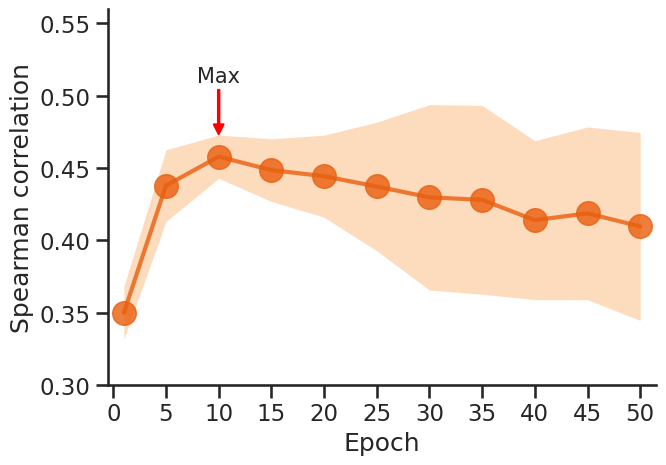

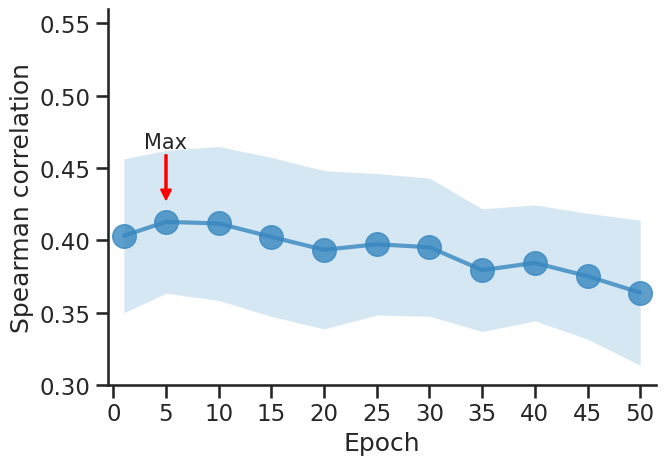

In [3]:
# Epoch vs Spearmanr
result = []

for file_path in glob("../results/prediction/finetuned/esm2_35M_*"):
    for epoch in  [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        db_size = os.path.basename(file_path).split("_")[2]
        data = pd.DataFrame(read_jsonl(os.path.join(file_path, f"epoch{epoch}", "scores_ridge.jsonl")))
        data.insert(0, "epoch", epoch)
        data.insert(0, "db_size", db_size)
        result.append(data)
result = pd.concat(result)
result = result.sort_values(["db_size", "epoch", "k"])


# Plot
xs = np.concatenate([np.array([1]), np.arange(5, 51, 5)])
for db_size in ["high", "low"]:
    if db_size == "high":
        cols = cols1
    if db_size == "low":
        cols = cols2
    mean_rho = result[result.db_size == db_size].groupby("epoch").spearmanr.mean()
    sd_rho = result[result.db_size == db_size].groupby("epoch").spearmanr.std()
    xmax = xs[np.argmax(mean_rho.values)]
    ymax = np.max(mean_rho.values)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(xs, mean_rho, "-o", markersize=17, linewidth=3.0, color=cols[1], alpha=0.8, label=f"Fine-tuned({db_size})")
    ax.fill_between(xs, mean_rho+sd_rho, mean_rho-sd_rho, color=cols[0], alpha=0.5, linewidth=0.0)
    ax.annotate(
        'Max',
        xy=(xmax, ymax+0.52*0.03),
        xytext=(xmax, ymax+0.52*0.12),
        arrowprops=dict(color='red', headwidth=7, width=1, headlength=7, shrink=0.0),
        horizontalalignment='center',
        verticalalignment='top',
        fontsize=15,
    )
    ax.set_xlim(-0.5, 51.5)
    ax.set_ylim(0.30, 0.56)
    ax.set_xticks(np.arange(0, 51, 5))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Spearman correlation")
    sns.despine()
    fig.tight_layout()
    fig.savefig(f"./figures/spearmanr-curve_{db_size}.svg")

In [4]:
# Summary of prediction scores

# Pretrained
pretrained_scores = []
for file_path in glob("../results/prediction/pretrained/*"):
    plm_size = int(os.path.basename(file_path).split("_")[2].replace("M", ""))
    data = pd.DataFrame(read_jsonl(os.path.join(file_path, "scores_ridge.jsonl")))
    data.insert(0, "epoch", "-")
    data.insert(0, "db_size", "-")
    data.insert(0, "plm_size", plm_size)
    pretrained_scores.append(data)
pretrained_scores = pd.concat(pretrained_scores).sort_values(["plm_size", "k"])


# Finetuned
result = []
for file_path in glob("../results/prediction/finetuned/*"):
    epoch_to_score = {}
    for epoch in range(5, 55, 5):
        data = pd.DataFrame(read_jsonl(os.path.join(file_path, f"epoch{epoch}", "scores_ridge.jsonl")))
        epoch_to_score[epoch] = data.spearmanr.mean()
    max_epoch = max(epoch_to_score, key=epoch_to_score.get)
    result.append({
        "model_name": os.path.basename(file_path),
        "epoch": max_epoch,
    })

finetuned_scores = []
for val in result:
    file_path = f"../results/prediction/finetuned/{val['model_name']}/epoch{val['epoch']}"
    plm_size = int(os.path.basename(os.path.dirname(file_path)).split("_")[1].replace("M", ""))
    db_size = os.path.basename(os.path.dirname(file_path)).split("_")[2]
    data = pd.DataFrame(read_jsonl(os.path.join(file_path, "scores_ridge.jsonl")))
    data.insert(0, "epoch", val["epoch"])
    data.insert(0, "db_size", db_size)
    data.insert(0, "plm_size", plm_size)
    finetuned_scores.append(data)
finetuned_scores = pd.concat(finetuned_scores, axis=0)


# Save
scores = pd.concat([pretrained_scores, finetuned_scores], axis=0)
scores = scores.sort_values(["plm_size", "db_size"])
scores.to_csv("./tables/scores_ridge.csv", index=False)

summary_table = scores.groupby(["plm_size", "db_size"], sort=True)[["pearsonr", "spearmanr", "recall_top5", "recall_top10", "precision_top5", "precision_top10"]].describe()
summary_table.reset_index(inplace=True)
summary_table.columns = [f"{i[0]}_{i[1]}" if i[1] != "" else i[0] for i in summary_table.columns]
summary_table.to_csv("./tables/summary_of_prediction_scores_ridge.csv", index=False)

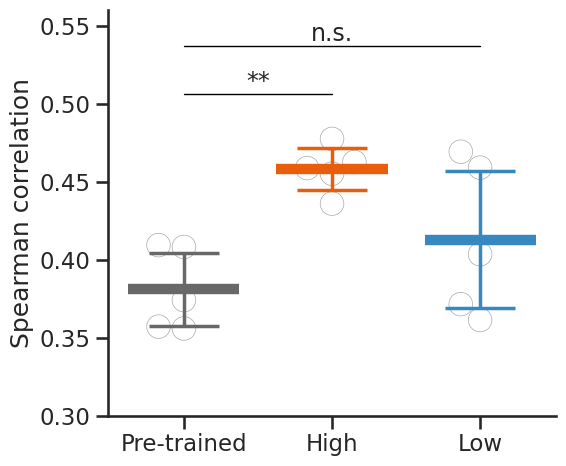

In [5]:
# Spearmanr at maximum point

scores_35m = scores[scores.plm_size == 35]
scores_35m.insert(1, "x", scores_35m.db_size.apply(lambda x: 0 if x == "-" else 1 if x == "high" else 2))

v1 = scores_35m[scores_35m.db_size == "-"].spearmanr.tolist()
v2 = scores_35m[scores_35m.db_size == "high"].spearmanr.tolist()
v3 = scores_35m[scores_35m.db_size == "low"].spearmanr.tolist()
p_values = stats.dunnett(v2, v3, control=v1).pvalue


# Plot
x = range(1, 4, 1)
vals = [rows.spearmanr.tolist() for _, rows in scores_35m.groupby("db_size")]

fig, ax = plt.subplots(figsize=(6, 5))
sns.swarmplot(
    ax=ax,
    data=scores_35m,
    x="x",
    y="spearmanr",
    hue="db_size",
    s=17,
    palette=["none", "none", "none"],
    edgecolor="darkgray",
    linewidth=0.5,
    zorder=1,
    legend=None
)
for pos, val, color in zip(range(3), vals, colors):
    sns.boxplot(
        showmeans=True,
        ax=ax,
        meanline=True,
        meanprops={'color': color, 'ls': '-', 'lw': 7.5},
        medianprops={'visible': False},
        whiskerprops={'visible': False},
        x=pos,
        y=val,
        showfliers=False,
        showbox=False,
        showcaps=False,
        width=0.75,
        zorder=2
    )
    ax.errorbar(pos, np.mean(val), np.std(val), lw=2.5, capthick=2.5, capsize=25, color=color, zorder=2)
barplot_annotate_brackets(
    0,
    1,
    annotation_text(p_values[0]),
    range(3),
    scores_35m.groupby("db_size").spearmanr.mean().tolist(),
    yerr=scores_35m.groupby("db_size").spearmanr.std().tolist(),
    dh=0.25,
    barh=0.0,
    linewidth=1,
    fs=17.0
)
barplot_annotate_brackets(
    0,
    2,
    annotation_text(p_values[1]),
    range(3),
    scores_35m.groupby("db_size").spearmanr.mean().tolist(),
    yerr=scores_35m.groupby("db_size").spearmanr.std().tolist(),
    dh=0.45,
    barh=0.0,
    linewidth=1,
    fs=17.0
)
ax.set_ylim(0.3, 0.56)
ax.set_xlabel("")
ax.set_ylabel("Spearman correlation")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Pre-trained", "High", "Low"])
ax.set_yticks(np.arange(0.3, 0.56, 0.05))
sns.despine()
fig.tight_layout()
fig.savefig("./figures/spearmanr_ridge_35m.svg")

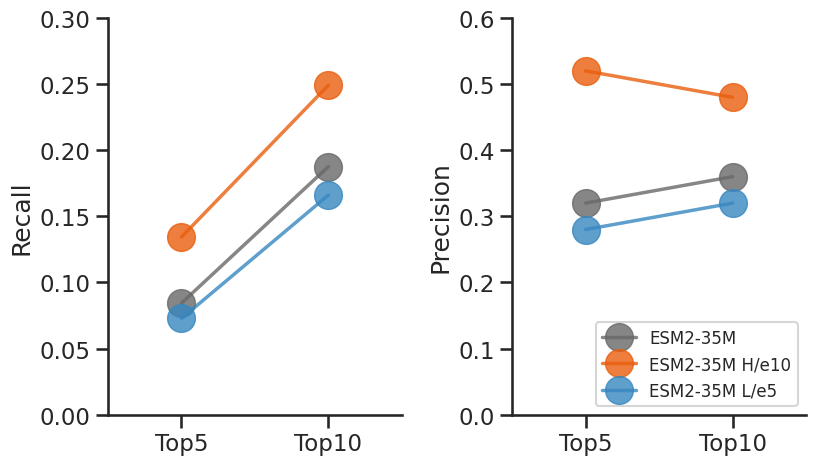

In [6]:
# Recall and precision
scores_35m = summary_table[summary_table.plm_size == 35]

fig, axes = plt.subplots(1, 2, figsize=(8.5, 5))
for i, rows in scores_35m.groupby("db_size"):
    if i == "-":
        col = cols3[1]
    if i == "high":
        col = cols1[1]
    if i == "low":
        col = cols2[1]
    axes[0].plot([0, 1], [rows.recall_top5_mean, rows.recall_top10_mean], "o-", markersize=20, linewidth=2.5, color=col, alpha=0.8, label=i)
    axes[1].plot([0, 1], [rows.precision_top5_mean, rows.precision_top10_mean], "o-", markersize=20, linewidth=2.5, color=col, alpha=0.8, label=i)
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(0.0, 0.3)
axes[0].set_xlabel("")
axes[0].set_ylabel("Recall")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Top5', 'Top10'], ha='center')
axes[0].set_yticks(np.arange(0, 0.35, 0.05))
axes[1].set_xlim(-0.5, 1.5)
axes[1].set_ylim(0.0, 0.6)
axes[1].set_xlabel("")
axes[1].set_ylabel("Precision")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Top5', 'Top10'], ha='center')
axes[1].legend(["ESM2-35M", "ESM2-35M H/e10", "ESM2-35M L/e5"], loc="lower right", fontsize=12)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/precision-recall_ridge_35m.svg", bbox_inches='tight')